In [1]:
import csv
import nibabel as nib
import matplotlib.pyplot as plt
import random
import torch
import os
import numpy as np
from model1 import CNN_3D,NiiDataset,MultiModalTransformer,NeuralNet,TransEModel,KGMultiModalTransformer
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import nibabel as nib
import shutil
import torch.nn as nn
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import math
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
import pandas as pd

In [33]:
path_existence = []
data_normal=[]
data_ad=[]
data_mci=[]
count_ad=0
count_no=0
count_mci=0
with open('NACC_normal.csv', mode='r', newline='', encoding='utf-8') as file:
    csv_reader = csv.reader(file)
    next(csv_reader)  
    for row in csv_reader:
        path = 'E:/code/NACC_nii_no/NACC_nii_no/' + row[1]
        exists = os.path.exists(path)
        path_existence.append((path, exists))
        if exists:
            count_no=count_no+1
            data_normal.append(row)
            
with open('NACC_ad.csv', mode='r', newline='', encoding='utf-8') as file:
    csv_reader = csv.reader(file)
    next(csv_reader) 
    for row in csv_reader:
        path = 'E:/code/NACC_nii_ad/NACC_nii_ad/' + row[1]
        exists = os.path.exists(path)
        path_existence.append((path, exists))
        if exists:
            count_ad=count_ad+1
            data_ad.append(row)
            
with open('NACC_mci.csv', mode='r', newline='', encoding='utf-8') as file:
    csv_reader = csv.reader(file)
    next(csv_reader) 
    for row in csv_reader:
        path = 'E:/code/NACC_mci/NACC_mci/' + row[1]
        exists = os.path.exists(path)
        path_existence.append((path, exists))
        if exists:
            count_mci=count_mci+1
            data_mci.append(row)
print(count_ad) #713
print(count_no) #2116
print(count_mci) #879

713
2116
879


In [34]:
ad_arrays=[]
replace_dict = {'female': '0', 'male': '1', 'whi': '0', 'blk': '1', '': '0','no':'0','yes':'1','ans':'2','haw':'3','ind':'4'}
for i in data_ad:
    j= i[27:]
    j= [replace_dict.get(item, item) for item in j]
    num_list = [float(num) for num in j]
    ad_array = np.array(num_list)
    ad_arrays.append(ad_array)
ad_array = np.vstack(ad_arrays)

In [35]:
normal_arrays=[]
for i in data_normal:
    j= i[27:]
    j= [replace_dict.get(item, item) for item in j]
    num_list = [float(num) for num in j]
    normal_array = np.array(num_list)
    normal_arrays.append(normal_array)
normal_array = np.vstack(normal_arrays)

In [36]:
mci_arrays=[]
for i in data_mci:
    j= i[27:]
    j= [replace_dict.get(item, item) for item in j]
    num_list = [float(num) for num in j]
    mci_array = np.array(num_list)
    mci_arrays.append(mci_array)
mci_array = np.vstack(mci_arrays)

In [37]:
#加权算值
def weighted_sum(tensor):
    weights = [0.2, 0.3, 0.5]
    weight_tensor = torch.tensor(weights, dtype=tensor.dtype, device=tensor.device)
    weighted_sum_result = torch.sum(tensor * weight_tensor, dim=1, keepdim=True)
    return weighted_sum_result

In [38]:
ad_tensor = torch.from_numpy(ad_array).float()
normal_tensor = torch.from_numpy(normal_array).float()
mci_tensor = torch.from_numpy(mci_array).float()
print(ad_tensor.shape)

normal_labels = torch.zeros(normal_tensor.shape[0], dtype=torch.long)
mci_labels = torch.ones(mci_tensor.shape[0], dtype=torch.long)
ad_labels = torch.full((ad_tensor.shape[0],), 2, dtype=torch.long)

X = torch.cat([ad_tensor, normal_tensor, mci_tensor], dim=0)
y = torch.cat([ad_labels, normal_labels, mci_labels], dim=0)

dataset = TensorDataset(X, y)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)
model = NeuralNet(embedding=81)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
for epoch in range(20):
    for inputs, labels in dataloader:
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()        
with torch.no_grad():
    ad_tensor = model(ad_tensor)
    normal_tensor = model(normal_tensor)
    mci_tensor = model(mci_tensor)
    
ad_tensor = weighted_sum(ad_tensor)
mci_tensor = weighted_sum(mci_tensor)
normal_tensor = weighted_sum(normal_tensor)

print('AD_tensor shape:', ad_tensor.shape)
print('Normal_tensor shape:', normal_tensor.shape)
print('MCI_tensor shape:', mci_tensor.shape)

torch.Size([713, 81])
AD_tensor shape: torch.Size([713, 1])
Normal_tensor shape: torch.Size([2116, 1])
MCI_tensor shape: torch.Size([879, 1])


In [39]:
# 数据处理函数
def preprocess_data(data, replace_dict):
    processed_data = []
    for row in data:
        row = [replace_dict.get(item, item) for item in row]
        row = [float(item) if item.replace('.', '', 1).isdigit() else item for item in row]
        processed_data.append(row[3:27])
    return np.array(processed_data)

In [40]:
# 编码类别型变量
def encode_categorical(data, categorical_indices):
    encoded_data = data.copy()
    for idx in categorical_indices:
        le = LabelEncoder()
        encoded_data[:, idx] = le.fit_transform(encoded_data[:, idx])
    return encoded_data.astype(float)

In [41]:
ad_data = preprocess_data(data_ad, replace_dict)
normal_data = preprocess_data(data_normal, replace_dict)
mci_data = preprocess_data(data_mci, replace_dict)

categorical_indices = [2, 3, 4, 5 ,6 ,7]  # gender, education, hispanic, race, apoe
ad_EHR = encode_categorical(ad_data, categorical_indices)
normal_EHR = encode_categorical(normal_data, categorical_indices)
mci_EHR = encode_categorical(mci_data, categorical_indices)

ad_EHR = torch.from_numpy(ad_EHR).float()
normal_EHR = torch.from_numpy(normal_EHR).float()
mci_EHR = torch.from_numpy(mci_EHR).float()

linear_layer = nn.Linear(24, 16)
normal_EHR = linear_layer(normal_EHR)
ad_EHR = linear_layer(ad_EHR)
mci_EHR = linear_layer(mci_EHR)

linear_layer = nn.Linear(16, 1)
normal_EHR = linear_layer(normal_EHR)
ad_EHR = linear_layer(ad_EHR)
mci_EHR = linear_layer(mci_EHR)

print('ad.EHR--->',ad_EHR.shape)
print('normal.EHR--->',normal_EHR.shape)
print('mci.EHR--->',mci_EHR.shape)

ad.EHR---> torch.Size([713, 1])
normal.EHR---> torch.Size([2116, 1])
mci.EHR---> torch.Size([879, 1])


In [42]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [43]:
import torch
import gc

# 1. 显式清理缓存，防止之前的残留占用显存
torch.cuda.empty_cache()
gc.collect()

# 医学图像模型初始化
nii = CNN_3D(num_class=1)
nii = nii.to(device)
# 2. 设置为评估模式 (关键)
nii.eval()

all_ad = 'NACC_nii_ad'
all_normal = 'NACC_nii_no'
all_mci = 'NACC_mci'

# 3. 减小 Batch Size (建议从 4 开始尝试，如果还爆显存改为 2 或 1)
batch_size = 4 

# --- 处理 AD ---
dataset = NiiDataset(all_ad)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
all_outputs = []

# 4. 使用 no_grad 上下文管理器 (关键：不计算梯度)
with torch.no_grad():
    for batch_idx, batch_data in enumerate(dataloader):
        batch_data = batch_data.to(device)
        output = nii(batch_data)
        # 5. 将结果 detach 并移至 CPU，防止显存堆积
        all_outputs.append(output.detach().cpu())

# 拼接后形状处理
ad_output = torch.cat(all_outputs, dim=0)
print('ad nii shape--->', ad_output.shape)

# 清理中间变量并释放显存
del all_outputs, dataset, dataloader
torch.cuda.empty_cache()

# --- 处理 Normal ---
dataset = NiiDataset(all_normal)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
all_outputs = []

with torch.no_grad():
    for batch_idx, batch_data in enumerate(dataloader):
        batch_data = batch_data.to(device)
        output = nii(batch_data)
        all_outputs.append(output.detach().cpu())

normal_output = torch.cat(all_outputs, dim=0)
print('normal nii shape--->', normal_output.shape)

del all_outputs, dataset, dataloader
torch.cuda.empty_cache()

# --- 处理 MCI ---
dataset = NiiDataset(all_mci)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
all_outputs = []

with torch.no_grad():
    for batch_idx, batch_data in enumerate(dataloader):
        batch_data = batch_data.to(device)
        output = nii(batch_data)
        all_outputs.append(output.detach().cpu())

mci_output = torch.cat(all_outputs, dim=0)
print('mci nii shape--->', mci_output.shape)

ad nii shape---> torch.Size([713, 1])
normal nii shape---> torch.Size([2116, 1])
mci nii shape---> torch.Size([879, 1])


In [53]:
import os
import pandas as pd
import torch

nii_folders = {
    'ad': 'NACC_nii_ad',
    'normal': 'NACC_nii_no',
    'mci': 'NACC_mci'
}

ad_df = pd.read_csv('NACC_ad.csv')
normal_df = pd.read_csv('NACC_normal.csv')
mci_df = pd.read_csv('NACC_mci.csv')

# 剔除的泄露标签列保持不变
exclude_cols = {'NC', 'MCI', 'DE', 'COG', 'AD', 'mmse', 'moca', 'cdr', 'cdrSum'}

entities = set()
for df in [ad_df, normal_df, mci_df]:
    for col in df.columns[8:]:
        if col not in exclude_cols:
            entities.update(df[col].astype(str).unique())

entities.update(df['ID'].astype(str).unique())

entity2id = {}
with open(r'd:/Polaris/Documents/work4/Baseline_CustomKG/Baseline&CustomKG/CustomKG/CustomKG-NACC.txt', 'r', encoding='utf-8') as f:
    for line in f:
        # 正确的映射关系
        id, entity = line.strip().split('\t')
        entity2id[entity] = id  

entity_embeddings = torch.from_numpy(np.load(r'd:/Polaris/Documents/work4/Baseline_CustomKG/Baseline&CustomKG/CustomKG/CustomKG-NACC.npy')).float()

# 定义TransE模型类
class TransEextract:
    def __init__(self, entity_embeddings, entity2id):
        self.entity_embeddings = entity_embeddings
        self.entity2id = entity2id
        self.id_to_index = {id: idx for idx, id in enumerate(sorted(entity2id.values()))}

    def get_entity_embedding(self, entity):
        if entity in self.entity2id:
            entity_id = self.entity2id[entity]
            entity_index = self.id_to_index[entity_id]
            return self.entity_embeddings[entity_index]
        else:
            raise ValueError(f"Entity {entity} not found in entity2id mapping")

# 初始化模型
model = TransEextract(entity_embeddings, entity2id)

# 获取嵌入向量
def get_embeddings(df, model, nii_folder):
    embeddings_list = []
    
    # 提前筛选出安全的特征列
    feature_cols = [col for col in df.columns[8:] if col not in exclude_cols]
    
    for index, row in df.iterrows():
        nii_file = row.iloc[1] 
        nii_path = os.path.join(nii_folder, nii_file)
        if not os.path.exists(nii_path):
            continue
        
        row_embeddings = []
        for col in feature_cols:  
            entity = str(row[col])
            if entity != '0' and entity !='' and entity in model.entity2id:
                row_embeddings.append(model.get_entity_embedding(entity))

        filename = str(row['ID'])
        if filename in model.entity2id:
            row_embeddings.append(model.get_entity_embedding(filename))
        
        if row_embeddings:
            mean_embedding = torch.stack(row_embeddings).mean(dim=0)
            embeddings_list.append(mean_embedding)
        else:
            # ★ 关键修改：如果没有匹配到任何图谱特征，用32维全0向量填充
            embeddings_list.append(torch.zeros(32))

    if not embeddings_list:
        return torch.empty((0, 32))
    
    return torch.stack(embeddings_list)

ad_transe = get_embeddings(ad_df, model, nii_folders['ad'])
mci_transe = get_embeddings(mci_df, model, nii_folders['mci'])
normal_transe = get_embeddings(normal_df, model, nii_folders['normal'])

print(f"ad_transe shape: {ad_transe.shape}")
print(f"mci_transe shape: {mci_transe.shape}")
print(f"normal_transe shape: {normal_transe.shape}")

ad_transe shape: torch.Size([713, 32])
mci_transe shape: torch.Size([879, 32])
normal_transe shape: torch.Size([2116, 32])


In [54]:
transe_embed_dim = 32
X_ad = torch.cat([ad_EHR, ad_output.cpu(), ad_tensor, ad_transe], dim=1)  # [batch_size_ad, EHR_dim + output_dim + tensor_dim + transe_embed_dim]
X_mci = torch.cat([mci_EHR, mci_output.cpu(), mci_tensor, mci_transe], dim=1)
X_normal = torch.cat([normal_EHR, normal_output.cpu(), normal_tensor, normal_transe], dim=1)

y_ad = torch.ones(len(X_ad)) * 2  # AD 类别标签为 2
y_mci = torch.ones(len(X_mci)) * 1  # MCI 类别标签为 1
y_normal = torch.ones(len(X_normal)) * 0  # Nc 类别标签为 0

X = torch.cat([X_ad, X_mci, X_normal], dim=0).float()
y = torch.cat([y_ad, y_mci, y_normal], dim=0).float()

features = X[:, :-transe_embed_dim]  
transe_embeddings = X[:, -transe_embed_dim:]  

X_train, X_test, y_train, y_test, transe_train, transe_test = train_test_split(
    features.detach().numpy(), y.numpy(), transe_embeddings.detach().numpy(),
    test_size=0.20,
    stratify=y.numpy(),
    random_state=32
)
X_train, X_val, y_train, y_val, transe_train, transe_val = train_test_split(
    X_train, y_train, transe_train,
    test_size=0.20,
    stratify=y_train,
    random_state=30
)


X_train_tensor = torch.FloatTensor(X_train).to(device)
y_train_tensor = torch.LongTensor(y_train).to(device)  # Use LongTensor for classification labels
transe_train_tensor = torch.FloatTensor(transe_train).to(device)

X_val_tensor = torch.FloatTensor(X_val).to(device)
y_val_tensor = torch.LongTensor(y_val).to(device)
transe_val_tensor = torch.FloatTensor(transe_val).to(device)

X_test_tensor = torch.FloatTensor(X_test).to(device)
y_test_tensor = torch.LongTensor(y_test).to(device)
transe_test_tensor = torch.FloatTensor(transe_test).to(device)


train_dataset = TensorDataset(X_train_tensor, transe_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, transe_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, transe_test_tensor, y_test_tensor)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

In [55]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    all_probs = []
    all_labels = []
    all_preds = []
    
    for inputs, transe_embed, labels in loader:
        inputs, transe_embed, labels = inputs.to(device), transe_embed.to(device), labels.to(device)
        labels = labels.long()
        
        optimizer.zero_grad()
        outputs = model(inputs, transe_embed)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()

        probs = torch.softmax(outputs, dim=1).detach().cpu().numpy()
        preds = torch.argmax(outputs, dim=1).detach().cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds)

    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)

    train_auc = roc_auc_score(all_labels, all_probs, multi_class='ovr')
    train_f1 = f1_score(all_labels, all_preds, average='macro')
    train_recall = recall_score(all_labels, all_preds, average='macro')
    train_precision = precision_score(all_labels, all_preds, average='macro')

    avg_loss = total_loss / len(loader)
    return avg_loss, train_auc, train_f1, train_recall, train_precision

def validate_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_probs = []
    all_labels = []
    all_preds = []
    with torch.no_grad():
        for inputs, transe_embed, labels in loader:
            inputs, transe_embed, labels = inputs.to(device), transe_embed.to(device), labels.to(device)
            labels = labels.long()
            
            outputs = model(inputs, transe_embed)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            probs = torch.softmax(outputs, dim=1).detach().cpu().numpy()
            preds = torch.argmax(outputs, dim=1).detach().cpu().numpy()
            all_probs.extend(probs)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds)
    
    
    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)

    # 计算指标
    val_auc = roc_auc_score(all_labels, all_probs, multi_class='ovo')
    val_f1 = f1_score(all_labels, all_preds, average='macro')
    val_recall = recall_score(all_labels, all_preds, average='macro')
    val_precision = precision_score(all_labels, all_preds, average='macro')
    
    # 计算平均损失
    avg_loss = total_loss / len(loader)
    return avg_loss, val_auc, val_f1, val_recall, val_precision


In [78]:
embed_dim = 32
transe_embed_dim = 32
num_epochs = 100
batch_size = 32
learning_rate = 1e-5
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
weight_decay = 1e-3

transe_model = TransEModel(num_entities=1698, num_relations=4, embed_dim=200)
transe_model.load_state_dict(torch.load('transe.ckpt', map_location=device))
transe_model.to(device)
transe_model.eval()

model = KGMultiModalTransformer(embed_dim=embed_dim, transe_embed_dim=transe_embed_dim).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate,weight_decay=weight_decay)

train_losses = []
train_aucs = []
train_f1s = []
train_recalls = []
train_precisions = []
test_losses = []
test_aucs = []
test_f1s = []
test_recalls = []
test_precisions = []

for epoch in range(num_epochs):
    train_loss, train_auc, train_f1, train_recall, train_precision = train_epoch(model, train_loader, optimizer, criterion, device)
    test_loss, test_auc, test_f1, test_recall, test_precision = validate_epoch(model, test_loader, criterion, device)
    
    train_losses.append(train_loss)
    train_aucs.append(train_auc)
    train_f1s.append(train_f1)
    train_recalls.append(train_recall)
    train_precisions.append(train_precision)
    
    test_losses.append(test_loss)
    test_aucs.append(test_auc)
    test_f1s.append(test_f1)
    test_recalls.append(test_recall)
    test_precisions.append(test_precision)
    
    if epoch % 10 == 0: print(f"Epoch {epoch + 1}/{num_epochs}, "
          f"Train Loss: {train_loss:.4f}, Train AUC: {train_auc:.4f}  "   
          f"test Loss: {test_loss:.4f}, test AUC: {test_auc:.4f}")

/tmp/ipykernel_10654/4049819273.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  transe_model.load_state_dict(torch.load('transe.ckpt', map_location=device))


Epoch 1/100, Train Loss: 1.1595, Train AUC: 0.4848  test Loss: 1.1287, test AUC: 0.4816
Epoch 2/100, Train Loss: 1.1562, Train AUC: 0.4975  test Loss: 1.1285, test AUC: 0.5140
Epoch 3/100, Train Loss: 1.1368, Train AUC: 0.5158  test Loss: 1.0976, test AUC: 0.5769
Epoch 4/100, Train Loss: 1.1246, Train AUC: 0.5198  test Loss: 1.0945, test AUC: 0.5852
Epoch 5/100, Train Loss: 1.1128, Train AUC: 0.5610  test Loss: 1.0874, test AUC: 0.6015
Epoch 6/100, Train Loss: 1.1022, Train AUC: 0.5705  test Loss: 1.0763, test AUC: 0.6063
Epoch 7/100, Train Loss: 1.0947, Train AUC: 0.5908  test Loss: 1.0710, test AUC: 0.6192
Epoch 8/100, Train Loss: 1.0785, Train AUC: 0.6082  test Loss: 1.0533, test AUC: 0.6283
Epoch 9/100, Train Loss: 1.0632, Train AUC: 0.6200  test Loss: 1.0395, test AUC: 0.6342
Epoch 10/100, Train Loss: 1.0546, Train AUC: 0.6216  test Loss: 1.0344, test AUC: 0.6425
Epoch 11/100, Train Loss: 1.0400, Train AUC: 0.6421  test Loss: 1.0070, test AUC: 0.6512
Epoch 12/100, Train Loss: 1.02

In [79]:
model.eval()
all_probs = []
all_labels = []
with torch.no_grad():
    for inputs, transe_embed, labels in val_loader:
        inputs, transe_embed, labels = inputs.to(device), transe_embed.to(device), labels.to(device)
        outputs = model(inputs, transe_embed)
        probs = torch.softmax(outputs, dim=1).cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(labels.cpu().numpy())

preds = np.argmax(all_probs, axis=1)
accuracy = accuracy_score(all_labels, preds)
precision = precision_score(all_labels, preds, average='macro')
recall = recall_score(all_labels, preds, average='macro')
f1 = f1_score(all_labels, preds, average='macro')
auc = roc_auc_score(all_labels, all_probs, multi_class='ovr')

print("\n=== Final Validation Metrics ===")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"AUC-ROC:   {auc:.4f}")


=== Final Validation Metrics ===
Accuracy:  0.6650
Recall:    0.5281
F1 Score:  0.4694
Precision: 0.4252
AUC-ROC:   0.7371


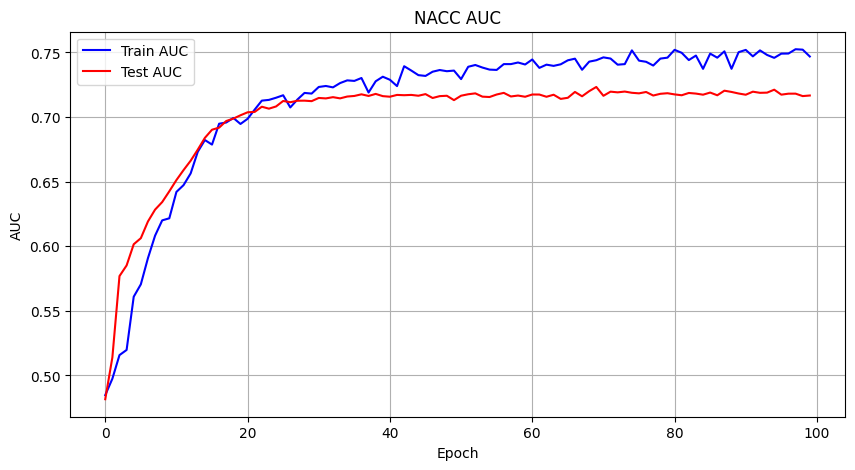

In [80]:
plt.figure(figsize=(10, 5))
plt.plot(range(len(train_aucs)), train_aucs, label="Train AUC", color="blue")
plt.plot(range(len(test_aucs)), test_aucs, label="Test AUC", color="red")
plt.title("NACC AUC")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.legend()
plt.grid(True)
plt.savefig('NACC_CustomKG_TransE_plot.png', dpi=300)
plt.close()

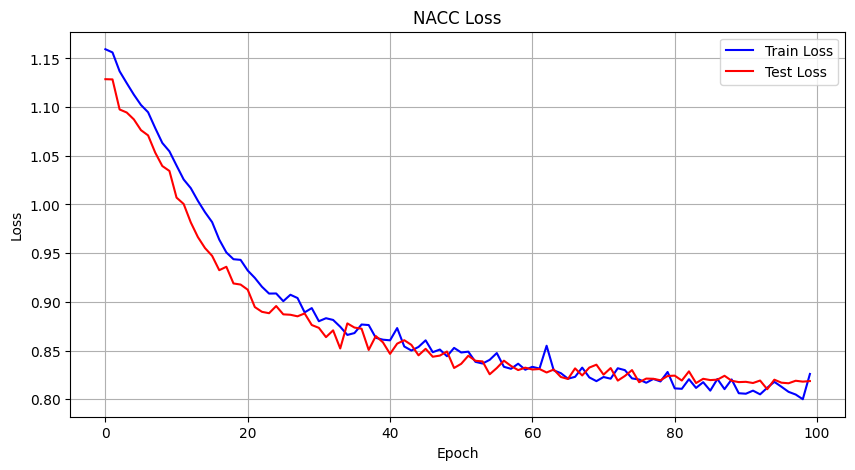

In [81]:
plt.figure(figsize=(10, 5))
plt.plot(range(len(train_losses)), train_losses, label="Train Loss", color="blue")
plt.plot(range(len(test_losses)), test_losses, label="Test Loss", color="red")
plt.title("NACC Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.savefig('NACC_CustomKG_TransE_plot.png', dpi=300)
plt.close()